<h1>Stochastic Models for Asset Returns</h1><h3>GBM, Heston & Merton</h3>


In this notebook, we try to investigate the ability of three stochastic models, Geometric 
Brownian Motion (GBM), Heston Stochastic Volatility, and Merton Jump Diffusion, to reproduce the empirical return behavior of real financial assets, we used 5(five) years of daily price data for AAPL, TSLA, and NVDA from 2020 to 2025, we first establish the statistical properties of real returns, then simulate 10,000 price paths under each model, and finally we compared the simulated distributions against NVDA's empirical returns to assess which model captures the fat tails, skewness, and volatility clustering observed in real market data.

In [2]:
# first we import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf

<h2>1. Environment and Data Eploration</h2>

In this phase, we analyze daily stock returns to uncover the fundamental statistical properties of financial data as well as compute basic moments, visualize return distributions, and compare them with a normal distribution to assess deviations such as skewness and leptokurtosis. Finally, we will also examine rolling volatility to identify periods of high and low market turbulence, showing the presence of volatility clustering, an important aspect of real-world financial returns.

In [3]:
# # getting the data from yfinance
# tickers = ["AAPL", "TSLA", "NVDA"]
# data = yf.download(tickers,start="2020-01-01", end="2025-01-01")

In [4]:
# data.to_csv("data.csv") #saving it

In [5]:
# price_data = pd.read_csv("data.csv") # reloading
price_data = pd.read_csv("data.csv", header=[0,1], index_col=0, skiprows=[2])

In [6]:
price_data.head()

Price           Close                            High                       \
Ticker           AAPL      NVDA       TSLA       AAPL      NVDA       TSLA   
2020-01-02  72.400520  5.970755  28.684000  72.460784  5.970755  28.713333   
2020-01-03  71.696640  5.875186  29.534000  72.455958  5.918988  30.266666   
2020-01-06  72.267906  5.899825  30.102667  72.306476  5.905051  30.104000   
2020-01-07  71.928078  5.971253  31.270666  72.533118  6.017046  31.441999   
2020-01-08  73.085106  5.982452  32.809334  73.386423  6.023765  33.232666   

Price             Low                            Open                       \
Ticker           AAPL      NVDA       TSLA       AAPL      NVDA       TSLA   
2020-01-02  71.156682  5.891364  28.114000  71.409785  5.941885  28.299999   
2020-01-03  71.472462  5.826158  29.128000  71.629145  5.851045  29.366667   
2020-01-06  70.568480  5.755727  29.333332  70.819178  5.781859  29.364668   
2020-01-07  71.708718  5.883152  30.224001  72.277601  5.928198  30.760000   
2020-01-08  71.631552  5.926953  31.215334  71.631552  5.967022  31.580000   

Price          Volume                        
Ticker           AAPL       NVDA       TSLA  
2020-01-02  135480400  237536000  142981500  
2020-01-03  146322800  205384000  266677500  
2020-01-06  118387200  262636000  151995000  
2020-01-07  108872000  314856000  268231500  
2020-01-08  132079200  277108000  467164500

In [46]:
prices = price_data["Close"]["NVDA"] # FOR NVDA
prices.head(10)

2020-01-02    5.970755
2020-01-03    5.875186
2020-01-06    5.899825
2020-01-07    5.971253
2020-01-08    5.982452
2020-01-09    6.048155
2020-01-10    6.080506
2020-01-13    6.271145
2020-01-14    6.154176
2020-01-15    6.111618
Name: NVDA, dtype: float64

**Computing daily log returns**

this is given as
$$
r_t = \ln\left(\frac{S_t}{S_{t-1}}\right)
$$


In [47]:
log_returns = np.log(prices / prices.shift(1))

# The first row becomes NaN because there is no previous day
log_returns = log_returns.dropna()

In [48]:
log_returns.head()

2020-01-03   -0.016136
2020-01-06    0.004185
2020-01-07    0.012034
2020-01-08    0.001874
2020-01-09    0.010923
Name: NVDA, dtype: float64

Good, now let us compute the statistical moments, we want to measure the shape of the return distribution.

In [12]:
mean_return = log_returns.mean() # Calculating  the mean of the return series

std_return = log_returns.std() # Calculate the standard deviation

skewy_return = log_returns.skew() # Calculate skewness

kurty_return = log_returns.kurtosis() # Calculate excess kurtosis. note that kurtosis measures how heavy the tails of the distribution are

# combining everything into a single table
stat_moments_table = pd.Series({
    "Mean": mean_return,
    "Std Dev": std_return,
    "Skewness": skewy_return,
    "Excess Kurtosis": kurty_return
})

In [13]:
# Display the results
stat_moments_table

Mean               0.002476
Std Dev            0.033712
Skewness           0.133987
Excess Kurtosis    3.479537
dtype: float64

Observe that the daily log returns of the asset have a positive mean of approximately 0.002476, showing a small upward drift over time, the standard deviation of 0.033712 shows moderate daily volatility, the positive skewness (0.133987) shows slightly more frequent or larger upside moves than downside moves. We should also note that the excess kurtosis of 3.479537 indicates fat tails, meaning extreme returns occur much more often than predicted by a normal distribution.


So now we ask ourselves, does the distribution actually look different from a normal distribution?, we have the numbers and yes numbers are useful, but visual evidence is stronger, so we will create a histogram of the empirical returns and then overlay the normal distribution with the same mean and volatility.

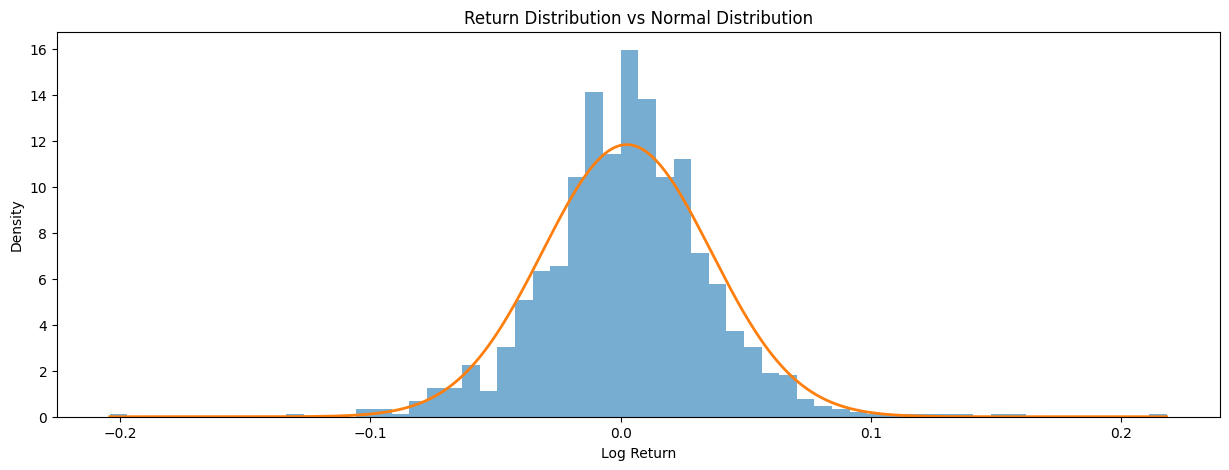

In [14]:
x = np.linspace(log_returns.min(), log_returns.max(), 500)
plt.figure(figsize=(15,5))

plt.hist(log_returns, bins=60, density=True, alpha=0.6)# density=True normalizes the histogram so it represents a probability density
plt.plot(x, stats.norm.pdf(x, mean_return, std_return), linewidth=2)# stats.norm.pdf computes the probability density of a normal distribution

plt.title("Return Distribution vs Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.show()

The histogram actually follows the normal curve quite closely, the peak is not dramatically sharper than the Gaussian overlay, and the tails don't show obvious heavy tail behavior visually, but the positive excess kurtosis tells us that there are heavier tails than a normal distribution would predict

Financial markets don’t have constant volatility, some periods are calm, others are stormy, this is known as volatility clustering: large moves tend to follow large moves, and small moves follow small moves. Visualizing rolling volatility will show us these clusters, many vol models assumes constant volatility, which clearly fails here

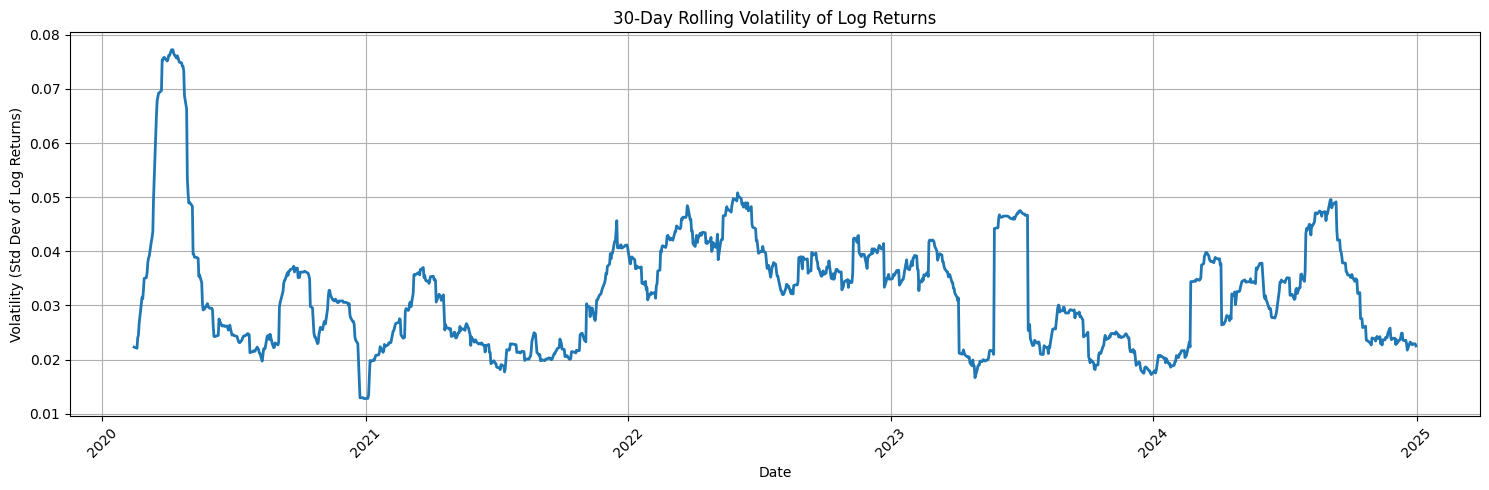

In [15]:
rolling_volatility = log_returns.rolling(window=30).std()
rolling_volatility.index = pd.to_datetime(rolling_volatility.index)

plt.figure(figsize=(15,5))
plt.plot(rolling_volatility, linewidth=2)
plt.title("30-Day Rolling Volatility of Log Returns")
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev of Log Returns)")
plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Observe the volatility clustering where large moves persistently follow large moves, we can see that NVDA's rolling volatility spikes sharply to 0.077 early in the series, likely the COVID-19 shock of 2020, and continues to show recurring elevated periods reaching 0.045–0.050 throughout, never fully settling

Thats all for Environment and Data Exploration, we move to the next phase:

<h2>2. Model Simulation</h2>

In this phase, we will simulate stock price dynamics using three classical models: Geometric Brownian Motion (GBM), Heston stochastic volatility, and Merton jump diffusion, our goal is simple: generate synthetic return distributions and examine how well each model captures important features of real financial returns, such as skewness, fat tails, and volatility clustering, when we compare simulated paths to our empirical data, we can assess the strengths and limitations of each modeling approach in reproducing observed market behavior.

*Geometric Brownian Motion (GBM)*

GBM is a continuous-time stochastic process that models asset prices as log-normally distributed with constant drift and constant volatility, forming the mathematical foundation of the Black-Scholes (Black and Scholes 637), the GBM assumes returns are log-normally distributed with constant drift (average return) and constant VOL. We simulate paths of stock prices over time using the Euler-Maruyama discretization of the GBM stochastic differential equation:

$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t
$$

where:

- $S_t$ = stock price at time $t$
- $\mu$ = drift (mean return)
- $\sigma$ = volatility (standard deviation of returns)
- $dW_t$ = increment of a standard Brownian motion

In [16]:
# GBM simulation (Euler-Maruyama)

np.random.seed(42)# Set the random seed so results are reproducible, dont ask why we used 42(lol)

S0 = 100
mu = mean_return
sigma = std_return
T = 1 # time horizon of the simulation (1 year)
N = 252 # number of time steps (252 trading days in a year)
dt = T / N # length of each time step
n_simulations = 10000# Number of simulated price paths
S_gbm = np.zeros((N + 1, n_simulations))# creates a matrix to store the simulated prices where the rows represent time steps, columns represent different simulations

S_gbm [0] = S0 # setting the first row equal to the initial stock price

# Simulate the GBM paths
for t in range(1, N + 1):
    
    # generate random shocks from a standard normal distribution
    Z = np.random.normal(0, 1, n_simulations)
    
    # euler-Maruyama
    S_gbm[t] = S_gbm[t-1] + mu * S_gbm[t-1] * dt + sigma * S_gbm[t-1] * np.sqrt(dt) * Z

In [17]:
print(S_gbm[t])

[106.20412327 103.38585992 100.0103214  ...  99.45357433  94.47437752
  97.39907348]


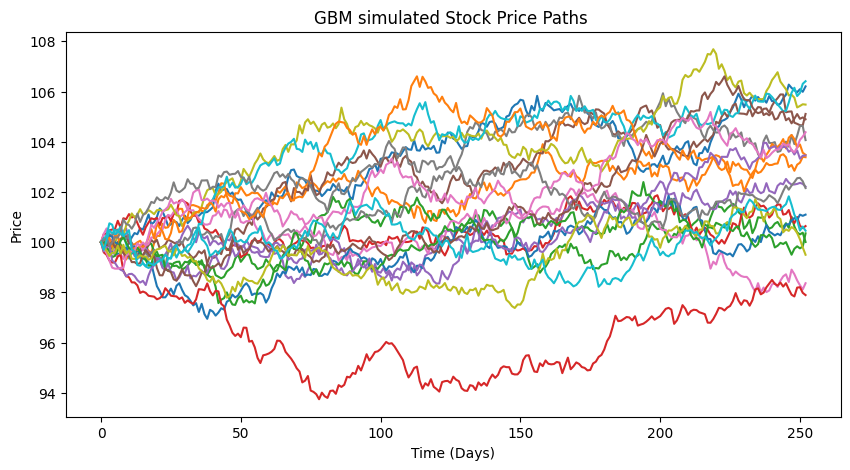

In [18]:
plt.figure(figsize=(10,5))
plt.plot(S_gbm[:, :20])#first 20 simulated price paths

plt.title("GBM simulated Stock Price Paths ")
plt.xlabel("Time (Days)")
plt.ylabel("Price")

plt.show()

We can see the stochastic nature of the Geometric Brownian Motion process, the simulated price paths all begin at the same initial value of 100 and gradually digresses as time progresses due to the accumulation of random shocks, some paths move upward while others moves downward. The widening spread of the trajectories shows that uncertainty increases over time, producing a range of possible future prices even when the model parameters remain fixed.

*Heston Stochastic Volatility Model*

The Heston model extends GBM by replacing constant volatility with a mean-reverting stochastic variance process, allowing it to reproduce the volatility smile that Black-Scholes cannot capture (Heston 327). This also captures the important empirical feature of financial markets: volatility clustering.

The model describes the joint evolution of the stock price and its variance through the following system of stochastic differential equations:

$$
dS_t = \mu S_t \, dt + \sqrt{v_t}\, S_t \, dW_t^S
$$

$$
dv_t = \kappa(\theta - v_t)\, dt + \xi \sqrt{v_t}\, dW_t^v
$$

where:

- $S_t$ = stock price at time $t$
- $v_t$ = instantaneous variance at time $t$
- $\mu$ = drift (expected return of the asset)
- $\kappa$ = rate at which variance reverts to its long-run level
- $\theta$ = long-run average variance
- $\xi$ = volatility of volatility (how strongly variance fluctuates)
- $dW_t^S$ = Brownian motion driving the stock price
- $dW_t^v$ = Brownian motion driving the variance process

The two Brownian motions are correlated:

$$
dW_t^S dW_t^v = \rho \, dt
$$

where $\rho$ represents the *correlation between asset returns and volatility shocks*, mainly -ve in equity markets, this structure allows the Heston model to generate more realistic return fluidity than GBM, including time-varying volatility and heavier tails in return distributions.

In [19]:
# Heston Stochastic Volatility Model (Euler-Maruyama)

np.random.seed(42) #42 again

# Parameters
S0 = 100          # initial price
v0 = std_return**2  # empirical variance
kappa = 3.0        # mean reversion speed of variance
theta = std_return**2  # long-run average variance
xi = 0.3           # Volatility of variance also known as vol of vol
rho = -0.7         # corr between price and variance shocks
T = 1              # 1 year
N = 252            # no of time steps
dt = T / N
n_simulations = 10000

# Storage matrices
S_heston = np.zeros((N + 1, n_simulations))  # stock price paths
v_heston = np.zeros((N + 1, n_simulations))  # variance paths

S_heston[0] = S0
v_heston[0] = v0

*Note:* The parameters v0, mu, and theta were derived directly from our empirical return data by computing the mean and variance of the log return series and the remaining parameters i.e kappa, xi, and rho were set to standard literature defaults commonly used for equity markets, while the correct approach is to calibrate all parameters simultaneously by fitting the model to either historical returns or options market data but these parameters represent structural properties of the variance process rather than quantities directly observable from price data alone, so we can use them but we can incorporate into a later notebook.

In [20]:
for t in range(1, N + 1):

    # generating 2 independent standard normal shocks
    Z1 = np.random.normal(0, 1, n_simulations)
    Z2 = np.random.normal(0, 1, n_simulations)

    # corr between price and variance shocks
    Z_S = Z1
    Z_v = rho * Z1 + np.sqrt(1 - rho**2) * Z2

    # variance process
    v_heston[t] = np.maximum(
        v_heston[t-1] + kappa * (theta - v_heston[t-1]) * dt + xi * np.sqrt(np.maximum(v_heston[t-1], 0) * dt) * Z_v,
        0
    )

    # stock process
    S_heston[t] = S_heston[t-1] + mu * S_heston[t-1] * dt + np.sqrt(np.maximum(v_heston[t-1], 0)) * S_heston[t-1] * np.sqrt(dt) * Z_S

In [21]:
S_heston[t]

array([102.53945124, 104.82369854, 102.02327185, ..., 102.26170543,
        96.85882583,  99.49220105], shape=(10000,))

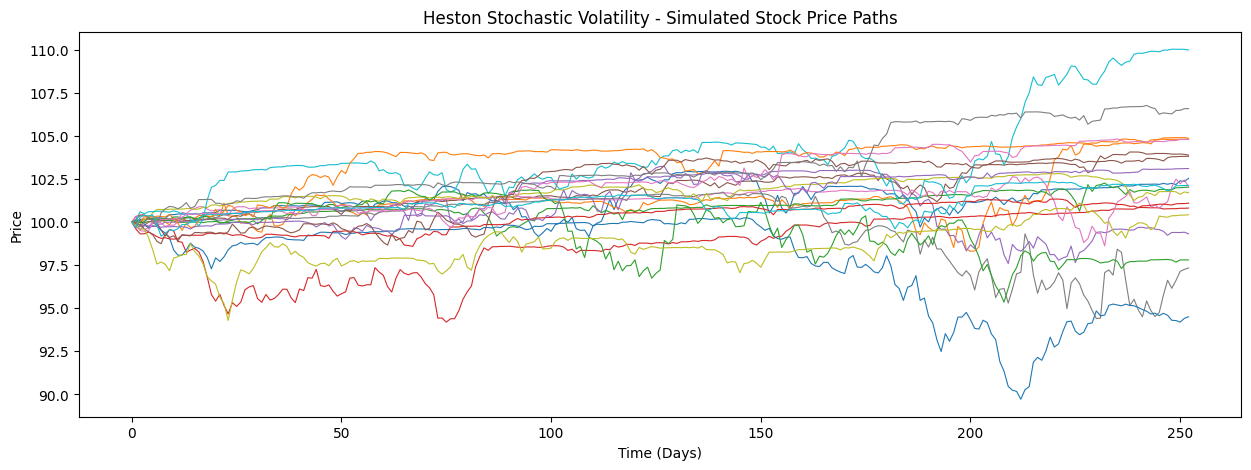

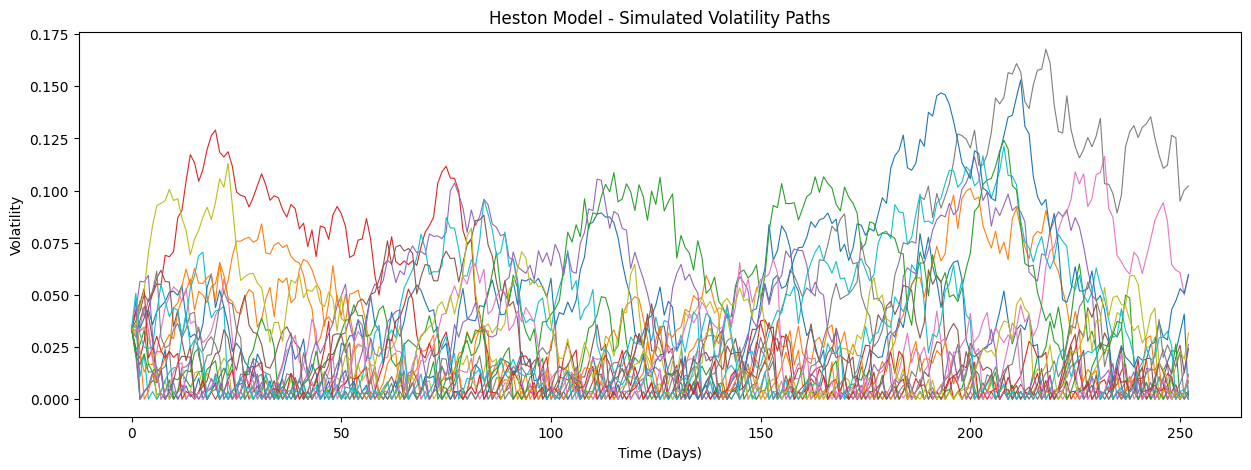

In [22]:
# Plot first 20 simulated price paths
plt.figure(figsize=(15, 5))
plt.plot(S_heston[:, :20], linewidth=0.8)
plt.title("Heston Stochastic Volatility - Simulated Stock Price Paths")
plt.xlabel("Time (Days)")
plt.ylabel("Price")
plt.show()

# Plot first 20 variance paths
plt.figure(figsize=(15, 5))
plt.plot(np.sqrt(v_heston[:, :20]), linewidth=0.8)  # Plot volatility (sqrt of variance)
plt.title("Heston Model - Simulated Volatility Paths")
plt.xlabel("Time (Days)")
plt.ylabel("Volatility")
plt.show()

Looking at the price paths plot, the trajectories fan out gradually from the initial price of 100, with most paths staying in a relatively tight band but a few diverging significantly, which is what we expected from a model where volatility itself is stochastic rather than fixed, in the volatility pathswe can clearly see volatility clustering in action, where some paths experience prolonged spikes while others remain low,showing that the CIR variance process is doing its job of letting volatility evolve randomly around the long-run mean.

*Merton Jump Diffusion Model*

The Merton model modifies the GBM with a compound Poisson jump process to capture sudden discontinuous price movements,producing the fat tails and excess kurtosis observed in real return distributions (Merton, 1976).

The stock price evolves as:

$$
dS_t = (\mu - \lambda \bar{k}) S_t \, dt + \sigma S_t \, dW_t + J_t S_t \, dN_t
$$

Where:
- $S_t$ = stock price at time $t$
- $\mu$ = continuous drift (expected return)
- $\sigma$ = continuous volatility (diffusion component)
- $dW_t$ = standard Brownian motion increment
- $\lambda$ = jump intensity (average number of jumps/year)
- $\bar{k} = e^{\mu_J + \frac{1}{2}\sigma_J^2} - 1$ = mean jump size, used to correct the drift so the model remains risk-neutral
- $dN_t$ = Poisson process increment, equals 1 if a jump occurs in $dt$, else 0
- $J_t$ = jump size, drawn from a log-normal distribution: $\ln(J) \sim \mathcal{N}(\mu_J, \sigma_J^2)$
- $\mu_J$ = mean of the log jump size
- $\sigma_J$ = standard deviation of the log jump size

In [23]:
# Merton Jump Diffusion Model (Euler-Maruyama)
np.random.seed(42)

# Params
S0 = 100
mu = mean_return
sigma = std_return
T = 1
N = 252
dt = T / N
n_simulations = 10000

# Jump params
lam = 5                     # Jump intensity (average 5 jumps per year)
mu_J = -0.02                # Mean log jump size (negative = crashes more common)
sigma_J = 0.03              # Std of log jump size

Please not that the jump params were also set to standard literature defaults commonly used for equity market the proper way to get them is through calibration, to be treated in future works

In [24]:
# Mean jump size correction (to adjust drift)
k_bar = np.exp(mu_J + 0.5 * sigma_J**2) - 1

# Storage matrix
S_merton = np.zeros((N + 1, n_simulations))
S_merton [0] = S0

# Simulate Merton paths
for t in range(1, N + 1):

    # Continuous diffusion shock
    Z = np.random.normal(0, 1, n_simulations)

    # no of jumps in each simulation during dt (Poisson distributed)
    N_jumps = np.random.poisson(lam * dt, n_simulations)

    # aggregate log jump size for each simulation
    J = np.random.normal(mu_J, sigma_J, n_simulations) * N_jumps

    # with jump component
    S_merton[t] = S_merton [t-1] + (mu - lam * k_bar) * S_merton [t-1] * dt \
           + sigma * S_merton [t-1] * np.sqrt(dt) * Z \
           + S_merton [t-1] * (np.exp(J) - 1)

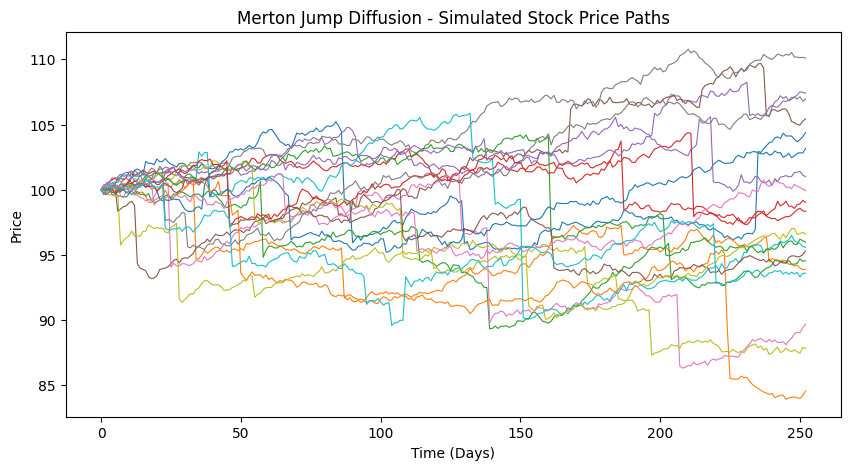

In [25]:
# Plot first 20 simulated price paths
plt.figure(figsize=(10, 5))
plt.plot(S_merton [:, :20], linewidth=0.8)
plt.title("Merton Jump Diffusion - Simulated Stock Price Paths")
plt.xlabel("Time (Days)")
plt.ylabel("Price")
plt.show()

Great, we can see that the Merton simulation looks exactly right,see the sudden discontinuities in the paths where the jumps occur, this is what separates it from GBM and Heston, the paths fan out more aggressively than GBM, and the downside jumps are visibly sharper than the upside ones.

**Simulated Return Distribution Comparison**

Okay now, having simulated 10,000 paths under each model, we now extract the terminal log returns, the log difference between the final and initial price for each path and plot all three distributions on the same axes, this allows us to directly COMPARE how each model reproduces the shape of the return distribution, particularly the tails.

In [26]:
# terminal log returns from each
gbm_returns = np.log(S_gbm[-1] / S_gbm[0])
heston_returns = np.log(S_heston[-1] / S_heston[0])
merton_returns = np.log(S_merton[-1] / S_merton[0])

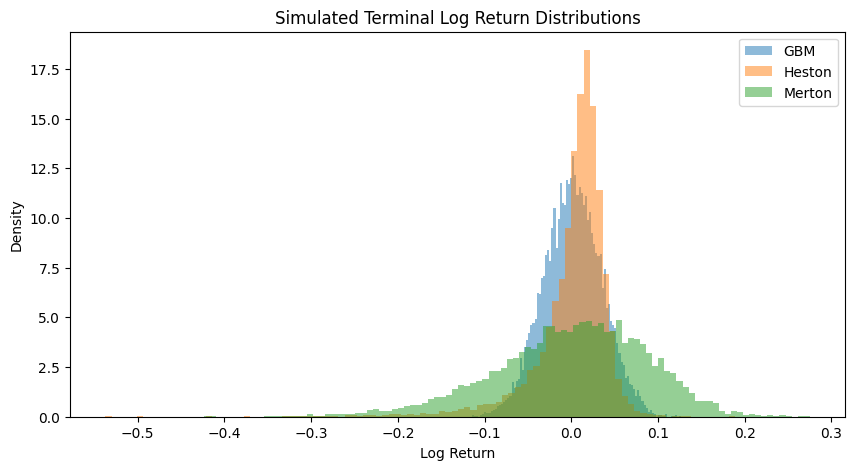

In [27]:
# all three distributions on the same axes
plt.figure(figsize=(10, 5))
plt.hist(gbm_returns, bins=100, density=True, alpha=0.5, label="GBM")
plt.hist(heston_returns, bins=100, density=True, alpha=0.5, label="Heston")
plt.hist(merton_returns, bins=100, density=True, alpha=0.5, label="Merton")
plt.title("Simulated Terminal Log Return Distributions")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

See how beautiful this is?, the GBM and Heston distributions are both tightly concentrated around zero with sharp peaks and narrow spreads, showing their deficiency to produce large sudden price movements with Heston being slightly more peaked due to the stochastic variance process compressing returns around the mean over the one-year period, the Merton distribution on the other hand, is wider and flatter, with probability mass extending as far as -0.5 and +0.3,because of compound Poisson jump process enforcing sudden large movements that neither GBM nor Heston can reproduce.

With the above image we can conclude that the jump diffusion is better equipped to capture the fat tails we observed earlier in our empirical return data, where we had excess kurtosis of 3.479537.

<h2>3. Empirical Comparison</h2>

We have simulated 10,000 price paths under 3 models GBM,Heston, and Merton and compared their terminal return distributions against each other. 
Now we take it a step further.

We pick NVDA's real returns, we then compare them side by side with the returns each model simulates using the mean and volatility of NVDA as inputs and we visually and numerically 
see which model's output looks most like what NVDA actually did.

We do this in three ways:first of all, we do an **overlay plot**, real NVDA returns plotted against all three simulated distributions on one chart, secondly, we draw a **moment comparison table**, mean, std, skewness, and excess kurtosis for NVDA vs all three models, then, the lastly we draw **QQ-plot**, a tail-specific diagnostic that shows how well each model tracks the extremes of the real distribution

In [30]:
nvda_prices = pd.to_numeric(price_data["Close"]["NVDA"], errors="coerce").dropna()
nvda_returns = np.log(nvda_prices / nvda_prices.shift(1)).dropna()

mu_nvda = nvda_returns.mean()
sigma_nvda = nvda_returns.std()

print(f"Mean :  {mu_nvda:.6f}")
print(f"Std Dev: {sigma_nvda:.6f}")

Mean :  0.002476
Std Dev: 0.033712


**GBM simulation**

In [31]:
np.random.seed(42)

S0 = 100
T = 1
N = 252
dt = T / N
n_simulations = 10000

In [32]:
S_gbm = np.zeros((N + 1, n_simulations))
S_gbm[0] = S0

for t in range(1, N + 1):
    Z = np.random.normal(0, 1, n_simulations)
    S_gbm[t] = S_gbm[t-1] + mu_nvda * S_gbm[t-1] * dt + sigma_nvda * S_gbm[t-1] * np.sqrt(dt) * Z

gbm_returns = np.log(S_gbm[-1] / S_gbm[0])

In [33]:
print(f"gbm_returns: {gbm_returns}")

gbm_returns: [ 0.06019275  0.03329802  0.00010321 ... -0.00547924 -0.05684153
 -0.02635349]


**Heston simulation**

In [34]:
np.random.seed(42)

v0 = sigma_nvda**2
kappa = 3.0
theta = sigma_nvda**2
xi = 0.3
rho = -0.7

S_heston = np.zeros((N + 1, n_simulations))
v = np.zeros((N + 1, n_simulations))
S_heston[0] = S0
v[0] = v0

In [35]:
for t in range(1, N + 1):
    Z1 = np.random.normal(0, 1, n_simulations)
    Z2 = np.random.normal(0, 1, n_simulations)
    Z_S = Z1
    Z_v = rho * Z1 + np.sqrt(1 - rho**2) * Z2
    v[t] = np.maximum(v[t-1] + kappa * (theta - v[t-1]) * dt + xi * np.sqrt(np.maximum(v[t-1], 0) * dt) * Z_v, 0)
    S_heston[t] = S_heston[t-1] + mu_nvda * S_heston[t-1] * dt + np.sqrt(np.maximum(v[t-1], 0)) * S_heston[t-1] * np.sqrt(dt) * Z_S

heston_returns = np.log(S_heston[-1] / S_heston[0])

In [36]:
print(f"heston_returns: {heston_returns}")

heston_returns: [ 0.02507743  0.04710969  0.02003076 ...  0.02236508 -0.03191567
 -0.00509093]


**Merton simulation**

In [37]:
np.random.seed(42)

lam = 5
mu_J = -0.02
sigma_J = 0.03
k_bar = np.exp(mu_J + 0.5 * sigma_J**2) - 1

S_merton = np.zeros((N + 1, n_simulations))
S_merton[0] = S0

In [38]:
for t in range(1, N + 1):
    Z = np.random.normal(0, 1, n_simulations)
    N_jumps = np.random.poisson(lam * dt, n_simulations)
    J = np.random.normal(mu_J, sigma_J, n_simulations) * N_jumps
    S_merton[t] = S_merton[t-1] + (mu_nvda - lam * k_bar) * S_merton[t-1] * dt \
                + sigma_nvda * S_merton[t-1] * np.sqrt(dt) * Z \
                + S_merton[t-1] * (np.exp(J) - 1)

merton_returns = np.log(S_merton[-1] / S_merton[0])

In [39]:
print(f"merton_returns: {merton_returns}")

merton_returns: [ 4.28548345e-02 -6.29589799e-02 -5.60554163e-02 ...  1.16715406e-04
  8.85665849e-02  1.28616437e-01]


In [40]:
print(f"Merton min: {merton_returns.min():.4f}, max: {merton_returns.max():.4f}")
print(f"GBM min: {gbm_returns.min():.4f}, max: {gbm_returns.max():.4f}")
print(f"Heston min: {heston_returns.min():.4f}, max: {heston_returns.max():.4f}")

Merton min: -0.4240, max: 0.2752
GBM min: -0.1148, max: 0.1269
Heston min: -0.5375, max: 0.1888


GBM and Heston are tightly clustered around zero

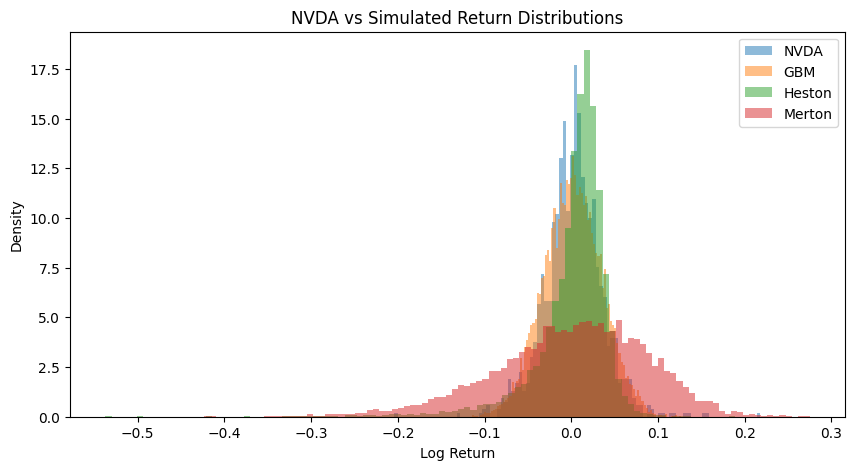

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(nvda_returns, bins=100, density=True, alpha=0.5, label="NVDA")
plt.hist(gbm_returns, bins=100, density=True, alpha=0.5, label="GBM")
plt.hist(heston_returns, bins=100, density=True, alpha=0.5, label="Heston")
plt.hist(merton_returns, bins=100, density=True, alpha=0.5, label="Merton")

plt.title("NVDA vs Simulated Return Distributions")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

Too clogged, lets plot side by side

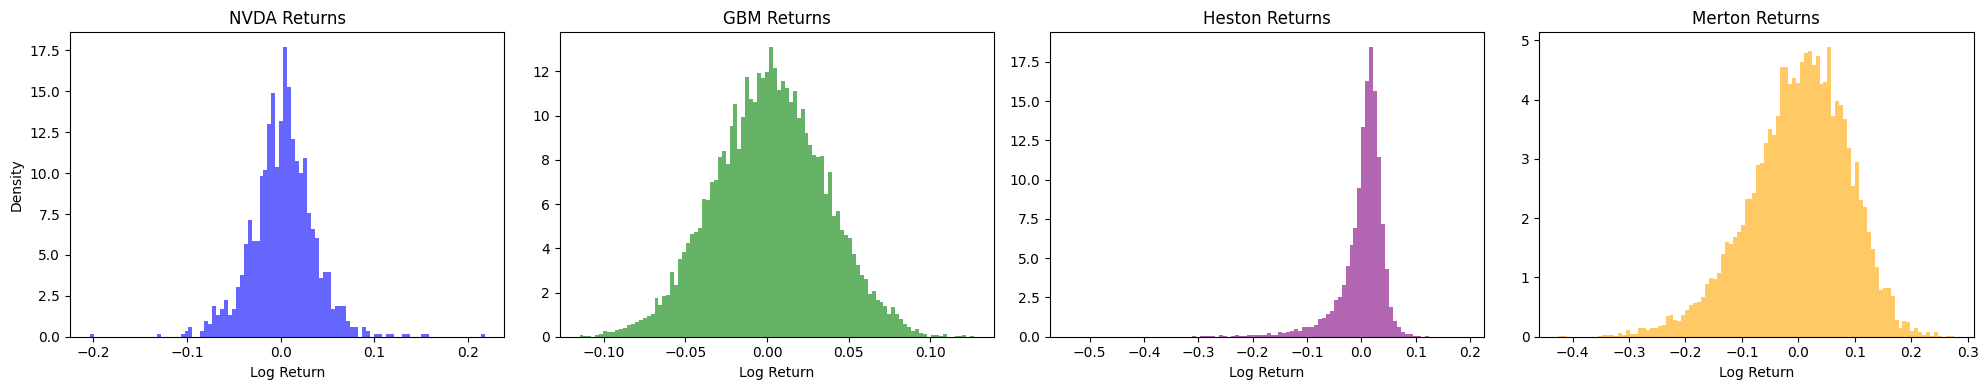

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# NVDA
axes[0].hist(nvda_returns, bins=100, density=True, alpha=0.6, color='blue')
axes[0].set_title("NVDA Returns")
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Density")

# GBM
axes[1].hist(gbm_returns, bins=100, density=True, alpha=0.6, color='green')
axes[1].set_title("GBM Returns")
axes[1].set_xlabel("Log Return")

# Heston
axes[2].hist(heston_returns, bins=100, density=True, alpha=0.6, color='purple')
axes[2].set_title("Heston Returns")
axes[2].set_xlabel("Log Return")

# Merton
axes[3].hist(merton_returns, bins=100, density=True, alpha=0.6, color='orange')
axes[3].set_title("Merton Returns")
axes[3].set_xlabel("Log Return")

plt.tight_layout()
plt.show()

Interesting, we can clearly see that Heston is the closest match, correctly reproducing NVDA's sharp central peak, though its slightly wider tails suggest xi(vol of vol) and kappa need calibration. Merton surprisily performs worst despite being designed for fat tails in theory, lam = 5 is likely too high for NVDA, over-dispersing the distribution and flattening the center to a density of only 5 compared to NVDA's 17.5, so like we said before, the parameters need proper calibration if they are to make the models perform better, but having looked at it visually, lets check what the numbers say.

Next we draw a moment comparison table, i.e mean, std, skewness, and excess kurtosis for NVDA vs all three models side by side

In [44]:
moment_table = pd.DataFrame({
    "NVDA": [
        nvda_returns.mean(),
        nvda_returns.std(),
        nvda_returns.skew(),
        nvda_returns.kurtosis()
    ],
    "GBM": [
        gbm_returns.mean(),
        gbm_returns.std(),
        pd.Series(gbm_returns).skew(),
        pd.Series(gbm_returns).kurtosis()
    ],
    "Heston": [
        heston_returns.mean(),
        heston_returns.std(),
        pd.Series(heston_returns).skew(),
        pd.Series(heston_returns).kurtosis()
    ],
    "Merton": [
        merton_returns.mean(),
        merton_returns.std(),
        pd.Series(merton_returns).skew(),
        pd.Series(merton_returns).kurtosis()
    ]
}, index=["Mean", "Std Dev", "Skewness", "Excess Kurtosis"])

moment_table.round(6)

,NVDA,GBM,Heston,Merton
Mean,0.002476,0.001660,0.001641,-0.000320
Std Dev,0.033712,0.033647,0.043140,0.087708
Skewness,0.133987,-0.018037,-2.686130,-0.484352
Excess Kurtosis,3.479537,-0.066616,13.883614,0.380577


GBM matches NVDA's mean and std closely, but its skewness of app -0.018 and excess kurtosis of app -0.067 confirm it produces a near-perfect normal distribution with no fat tails, which is at par with its theoretical limitations (Black and Scholes, 1973). Heston overshoots with skewness of -2.686 and excess kurtosis of 13.884, a known consequence of uncalibration where kappa, xi, and rho must be jointly fitted to produce realistic shapes (Gatheral, 2006). Merton's skewness of -0.484 and kurtosis of 0.381 both underfit NVDA's empirical values, pointing to lambda = 5 being too high, Cont (2001) documents that jump intensity between 1 and 3 per year is more consistent with equity markets.

Lets check the qq plots for each model against NVDA's empirical returns, showing how well each model tracks the extremes of the real distribution

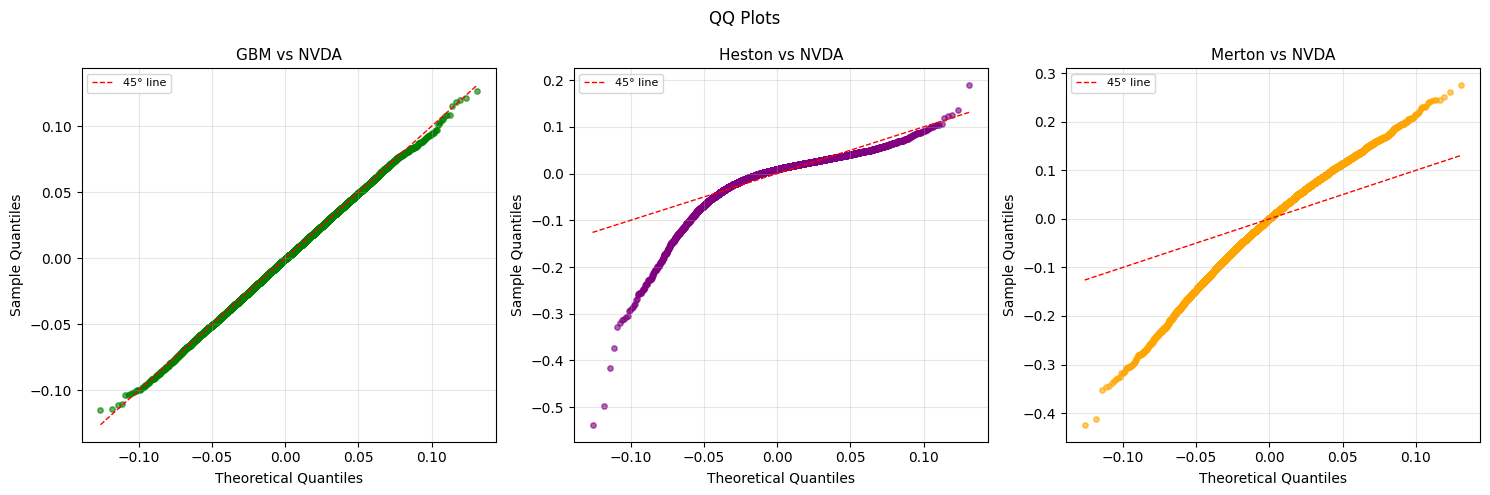

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [
    (gbm_returns, "GBM vs NVDA", "green"),
    (heston_returns, "Heston vs NVDA", "purple"),
    (merton_returns, "Merton vs NVDA", "orange")
]

for ax, (returns, title, color) in zip(axes, models):
    osm, osr = stats.probplot(returns, dist=stats.norm, 
                               sparams=(nvda_returns.mean(), nvda_returns.std()))[0]
    ax.scatter(osm, osr, s=15, color=color, alpha=0.6)
    ax.plot(osm, osm, color="red", linewidth=1, linestyle="--", label="45° line")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("QQ Plots")
plt.tight_layout()
plt.show()

GBM hugs the diagonal most closely in the center but curves away at both tails, it underestimates extreme returns, Heston overshoots the left tail, with simulated quantiles reaching against NVDA, showing it generates far more severe downside events than actually occur. Merton shows an S-shaped curve that crosses the diagonal, meaning it overestimates tail width in both directions while underestimating the central concentration, none of the three models perfectly track NVDA's empirical quantiles, this means calibration(which is lacking) is essential before any of these models can be used for practical risk assessment, which will be don in a later notebook.

## Conclusion

This notebook investigated the ability of three classical stochastic models,the Geometric Brownian Motion, the Heston Stochastic Volatility, and the Merton Jump Diffusion, to reproduce the empirical return behavior of NVDA over a five-year period from 2020 to 2025, and we worked in three phases.

The empirical analysis in Phase 1 shows that NVDA daily log returns are not normal,which gave mean 0.002476, std 0.033712, skewness 0.133987, and excess kurtosis 3.479537, showing that there are fat tails and volatility clustering that any credible model must account for.

In Phase 2, we simulated all three models over 10,000 paths using a one-year horizon. GBM produced smooth and symmetric paths, Heston showed stochastic variance through the CIR process, generating time-varying volatility and clustering and Merton added compound Poisson jumps.

The empirical comparison in Phase 3 revealed that none of the three models perfectly reproduces NVDA's return distribution under default parameters. GBM failed by producing a  near-zero skewness and kurtosis. Heston gave an extreme skewness of -2.686 and kurtosis of 13.884. Merton over-disperses the distribution, probably due to an uncalibrated parameters

So with these results we conclude that literature default parameters are insufficient for model validation against real asset data and calibration of models of the utmost importance for without it models fail. The best step to take now (in subsequent notebooks) is to calibrate all three models and test it again with NVDA and see if each model will yield meaningful and comparable results.

so our subsequent notebook will answer: **Which model matches NVDA best?**, 
**How sensitive are the results to parameter calibration?**

watch out for our next notebook:

*Model Calibration for GBM, Heston, and Merton.*

References

Black, Fischer, and Myron Scholes. "The Pricing of Options and Corporate Liabilities." Journal of Political Economy, vol. 81, no. 3, 1973, pp. 637–654.

Heston, Steven L. "A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options." The Review of Financial Studies, vol. 6, no. 2, 1993, pp. 327–343.

Merton, Robert C. "Option Pricing When Underlying Stock Returns Are Discontinuous." Journal of Financial Economics, vol. 3, no. 1–2, 1976, pp. 125–144.

Cont, Rama. "Empirical Properties of Asset Returns: Stylized Facts and Statistical Issues." Quantitative Finance, vol. 1, no. 2, 2001, pp. 223–236.

Gatheral, Jim. The Volatility Surface: A Practitioner's Guide. Wiley Finance, 2006.

Worldquant University, MScFE, Derivative Pricing Course 2026